In [4]:
import pandas as pd

# Path to your CSV file
file_path = '/Users/mhaefke/anaconda_projects/Applied Machine Learning/Group Project/csv_pny/psam_p36.csv'

# Read CSV into a DataFrame
df = pd.read_csv(file_path)

# Check if there are duplicates in SERIALNO
duplicates = df[df. SERIALNO.duplicated(keep=False)]

# Display duplicate rows (if any)
duplicates

,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
13862,P,2023HU0000129,2,1,4502,1,36,1019518,85,71,...,26,105,131,71,81,29,87,108,89,78
13863,P,2023HU0000129,2,2,4502,1,36,1019518,75,42,...,22,110,113,57,72,29,82,86,71,76
13864,P,2023HU0000136,2,1,2500,1,36,1019518,26,34,...,6,25,27,44,28,40,50,10,9,28
13865,P,2023HU0000136,2,2,2500,1,36,1019518,30,34,...,10,33,27,52,33,47,47,7,10,32
13866,P,2023HU0000136,2,3,2500,1,36,1019518,28,11,...,8,31,29,46,35,47,54,7,10,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206403,P,2023HU1459885,2,4,4503,1,36,1019518,36,61,...,9,14,40,40,63,63,11,40,37,12
206404,P,2023HU1459885,2,5,4503,1,36,1019518,50,60,...,13,15,50,58,87,76,13,50,47,16
206405,P,2023HU1459895,2,1,2201,1,36,1019518,112,28,...,161,28,94,35,118,101,116,33,41,25
206406,P,2023HU1459895,2,2,2201,1,36,1019518,25,4,...,40,8,28,11,32,24,20,10,6,8


In [1]:
import pandas as pd

# Path to your CSV
csv_path = "csv_pny/psam_p36.csv"

# Relevant columns: Unique ID + Health Insurance Coverage
usecols = [
    "SERIALNO",  # Household ID
    "SPORDER",   # Person number within the household
    "HICOV",     # Health insurance coverage (recode)
    "PRIVCOV",   # Private coverage (recode)
    "PUBCOV",    # Public coverage (recode)
    "HINS1", "HINS2", "HINS3", "HINS4", "HINS5", "HINS6", "HINS7"
]

# Read the CSV – only the relevant columns
df = pd.read_csv(csv_path, usecols=usecols)

# Create a unique person ID (household ID + person order)
df["PERSONID"] = (
    df["SERIALNO"].astype(str)
    + "_"
    + df["SPORDER"].astype(str).str.zfill(2)
)

# Reorder columns: ID first, then the insurance variables
cols_order = [
    "PERSONID",
    "HICOV", "PRIVCOV", "PUBCOV",
    "HINS1", "HINS2", "HINS3", "HINS4", "HINS5", "HINS6", "HINS7"
]

df = df[cols_order]

df = df.rename(columns={
    "HINS1": "HINS1_EMPLOYER",
    "HINS2": "HINS2_DIRECT_PURCHASE",
    "HINS3": "HINS3_MEDICARE",
    "HINS4": "HINS4_MEDICAID",
    "HINS5": "HINS5_TRICARE",
    "HINS6": "HINS6_VA",
    "HINS7": "HINS7_IHS"
})

# Display the first 20 rows
df.head(20)


,PERSONID,HICOV,PRIVCOV,PUBCOV,HINS1_EMPLOYER,HINS2_DIRECT_PURCHASE,HINS3_MEDICARE,HINS4_MEDICAID,HINS5_TRICARE,HINS6_VA,HINS7_IHS
0,2023GQ0000006_01,1,1,2,1,1,2,2,2,2,2
1,2023GQ0000012_01,1,2,1,2,2,2,1,2,2,2
2,2023GQ0000015_01,1,2,1,2,2,1,1,2,2,2
3,2023GQ0000016_01,1,2,1,2,2,2,1,2,2,2
4,2023GQ0000049_01,1,2,1,2,2,1,2,2,2,2
5,2023GQ0000060_01,1,2,1,2,2,2,1,2,2,2
6,2023GQ0000062_01,1,2,1,2,2,2,1,2,2,2
7,2023GQ0000090_01,1,2,1,2,2,1,2,2,2,2
8,2023GQ0000092_01,1,1,2,1,2,2,2,2,2,2
9,2023GQ0000095_01,1,1,2,2,1,2,2,2,2,2


In [24]:
# --- People WITHOUT any health insurance (HICOV = 2) ---
# Show a few example rows of uninsured individuals
print(df[df["HICOV"] == 2].head())

# Count how many people have no health insurance
num_uninsured = (df["HICOV"] == 2).sum()
print("Number without health insurance:", num_uninsured)

# Percentage of people who are uninsured
percent_uninsured = (df["HICOV"] == 2).mean() * 100
print(f"Percentage without health insurance: {percent_uninsured:.2f}%")
print()


# --- People WITH any health insurance (HICOV = 1) ---
# Show a few example rows of insured individuals
print(df[df["HICOV"] == 1].head())

# Count how many people have health insurance
num_insured = (df["HICOV"] == 1).sum()
print("Number with health insurance:", num_insured)

# Percentage of people who are insured
percent_insured = (df["HICOV"] == 1).mean() * 100
print(f"Percentage with health insurance: {percent_insured:.2f}%")

            PERSONID  HICOV  PRIVCOV  PUBCOV  HINS1_EMPLOYER  \
47  2023GQ0000570_01      2        2       2               2   
56  2023GQ0000704_01      2        2       2               2   
66  2023GQ0000832_01      2        2       2               2   
78  2023GQ0000952_01      2        2       2               2   
99  2023GQ0001221_01      2        2       2               2   

    HINS2_DIRECT_PURCHASE  HINS3_MEDICARE  HINS4_MEDICAID  HINS5_TRICARE  \
47                      2               2               2              2   
56                      2               2               2              2   
66                      2               2               2              2   
78                      2               2               2              2   
99                      2               2               2              2   

    HINS6_VA  HINS7_IHS  
47         2          2  
56         2          2  
66         2          2  
78         2          2  
99         2          2  
Nu

HICOV: 95.79% have value 1, 0.00% missing
PRIVCOV: 66.25% have value 1, 0.00% missing
PUBCOV: 45.06% have value 1, 0.00% missing
HINS1_EMPLOYER: 55.16% have value 1, 0.00% missing
HINS2_DIRECT_PURCHASE: 14.12% have value 1, 0.00% missing
HINS3_MEDICARE: 24.69% have value 1, 0.00% missing
HINS4_MEDICAID: 26.64% have value 1, 0.00% missing
HINS5_TRICARE: 1.35% have value 1, 0.00% missing
HINS6_VA: 1.64% have value 1, 0.00% missing
HINS7_IHS: 0.15% have value 1, 0.00% missing


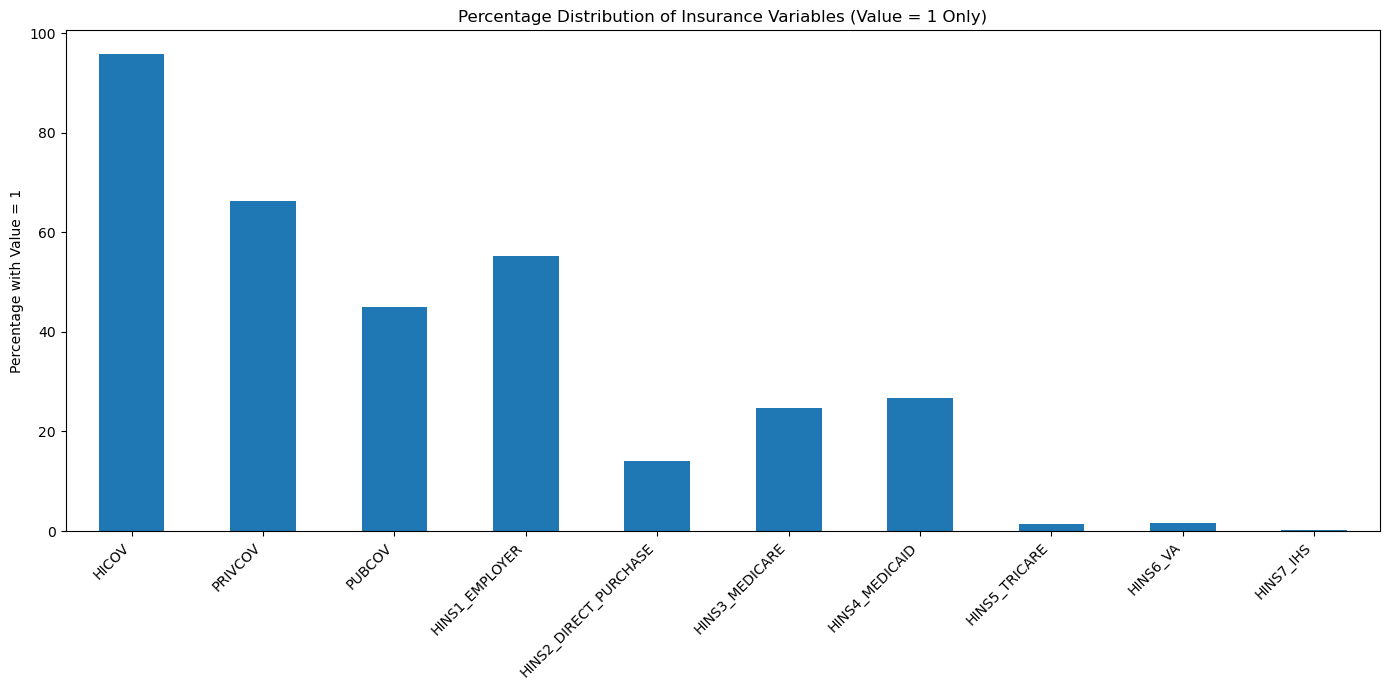

In [51]:
# List of all insurance variables (updated with new HINS names)
insurance_vars = [
    "HICOV",
    "PRIVCOV",
    "PUBCOV",
    "HINS1_EMPLOYER",
    "HINS2_DIRECT_PURCHASE",
    "HINS3_MEDICARE",
    "HINS4_MEDICAID",
    "HINS5_TRICARE",
    "HINS6_VA",
    "HINS7_IHS"
]

# Show percentage for value = 1 and missing percentage
for var in insurance_vars:
    pct_1 = (df[var] == 1).mean() * 100
    missing_pct = df[var].isna().mean() * 100
    print(f"{var}: {pct_1:.2f}% have value 1, {missing_pct:.2f}% missing")

# Build table (only value = 1 percentages)
perc_df = pd.DataFrame({
    "Percent_1": [(df[var] == 1).mean() * 100 for var in insurance_vars]
}, index=insurance_vars)

# Plot percentage distribution (value = 1 only)
perc_df.plot(kind="bar", legend=False, figsize=(14, 7))
plt.ylabel("Percentage with Value = 1")
plt.title("Percentage Distribution of Insurance Variables (Value = 1 Only)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

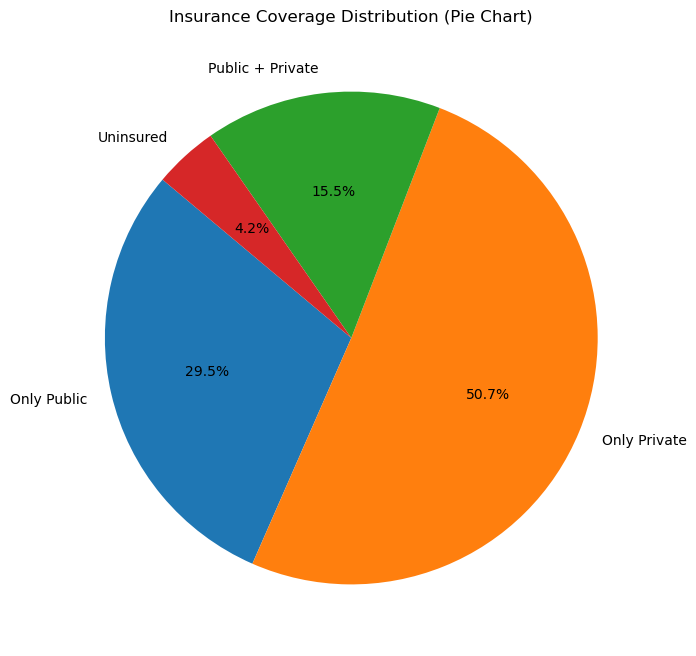

In [54]:
# Define insurance groups
only_public = (df["PUBCOV"] == 1) & (df["PRIVCOV"] == 2)
only_private = (df["PRIVCOV"] == 1) & (df["PUBCOV"] == 2)
both = (df["PRIVCOV"] == 1) & (df["PUBCOV"] == 1)
uninsured = df["HICOV"] == 2

# Calculate percentages
results = {
    "Only Public": only_public.mean() * 100,
    "Only Private": only_private.mean() * 100,
    "Public + Private": both.mean() * 100,
    "Uninsured": uninsured.mean() * 100
}

# Pie chart
labels = list(results.keys())
sizes = list(results.values())

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Insurance Coverage Distribution (Pie Chart)")
plt.show()